In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.spectograms import SpectogramConfig
from src.model_trainer import ModelTrainer
from src.image_preprocessor import ImagePreprocessor
from src.gradcam import GradCam
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from IPython.display import Image, display

/Users/camcortes/Documents/birds-sounds/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
preprocessor = ImagePreprocessor()
data = preprocessor.load_data_from_directory("../src/data/images_test/images_spectograms")

In [6]:
model_name = "ResNet152V2" #"EfficientNetV2L" #"ResNet152V2" #"EfficientNetB7"

model_trainer = ModelTrainer(
    model_name=model_name,
    img_shape=(128, 256, 1),
    n_classes=667,
    dropout_rate=0.2,
    label_smoothing=0.1,
    fine_tune_layers=200
)

model = model_trainer.create_model()
model.summary()
model.load_weights(f"models/weights_{model_name}.weights.h5")
tf.keras.backend.clear_session()

Model: "ResNet152V2_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 256, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_3 (Lambda)               │ (None, 128, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess_input (Lambda)       │ (None, 128, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet152v2 (Functional)        │ (None, 2048)           │    58,331,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ top_dropout (Dropout)           │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 667)            │     1,366,683 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,698,331 (227.73 MB)

 Trainable params: 32,846,491 (125.30 MB)

 Non-trainable params: 26,851,840 (102.43 MB)

/Users/camcortes/Documents/birds-sounds/.venv/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 368 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
data = data[data["label"] == "Acropternis orthonyx"]

Specie: Acropternis orthonyx



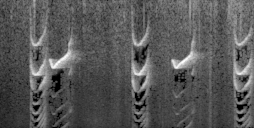

In [17]:
random = np.random.randint(0, data.shape[0])
print(f'Specie: {data.label[random]}\n')
img_path = data['image_path'][random]
display(Image(img_path))

In [18]:
gradcam = GradCam(model, model_name=model_name)

/Users/camcortes/Documents/birds-sounds/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_1251']]
Received: inputs=Tensor(shape=(1, 128, 256, 3))
  warnings.warn(msg)


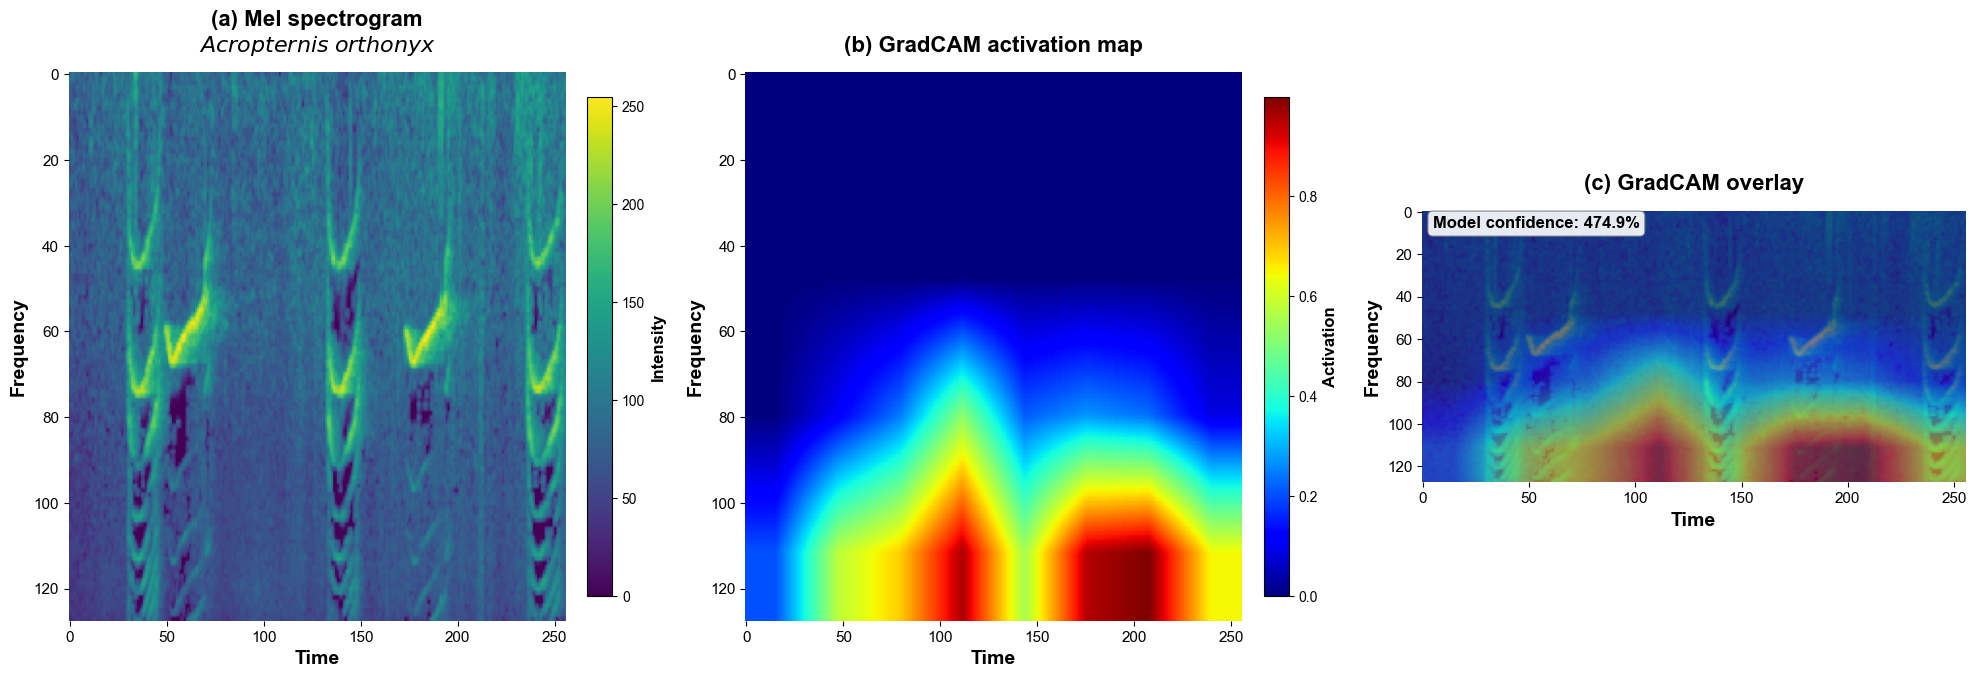


📊 Gráfico guardado en: ../fig/gradcam_analysis.png y .pdf
🎯 Especie: Acropternis orthonyx
📈 Confianza del modelo: 474.9%


In [ ]:
heatmap, original_img, class_output = gradcam.generate_gradcam(img_path)

# ===== CONFIGURACIÓN DE ESTILO CIENTÍFICO =====
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'axes.linewidth': 0.8,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor='white')

# --- PANEL A: Espectrograma Mel con colormap viridis ---
if len(original_img.shape) == 3:
    original_gray = cv2.cvtColor(original_img, cv2.COLOR_RGB2GRAY)
    im1 = axes[0].imshow(original_gray, cmap='viridis', aspect='auto')
else:
    im1 = axes[0].imshow(original_img, cmap='viridis', aspect='auto')

# Formatear nombre de especie en itálica
species_name = data.label[random]
genus_species = species_name.split()
if len(genus_species) >= 2:
    titulo_italica = f"$\it{{{genus_species[0]}}}$ $\it{{{genus_species[1]}}}$"
else:
    titulo_italica = f"$\it{{{species_name}}}$"

axes[0].set_title(f'(a) Mel spectrogram\n{titulo_italica}', fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('Time', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=14, fontweight='bold')
axes[0].tick_params(labelsize=11)

# Añadir colorbar
cbar1 = plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04)
cbar1.set_label('Intensity', fontsize=12, fontweight='bold')
cbar1.ax.tick_params(labelsize=10)

# --- PANEL B: Mapa de calor GradCAM ---
im2 = axes[1].imshow(heatmap, cmap="jet", aspect='auto')
axes[1].set_title('(b) GradCAM activation map', fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel('Time', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=14, fontweight='bold')
axes[1].tick_params(labelsize=11)

# Añadir colorbar
cbar2 = plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04)
cbar2.set_label('Activation', fontsize=12, fontweight='bold')
cbar2.ax.tick_params(labelsize=10)

# --- PANEL C: Superposición ---
# Convertir espectrograma a viridis para la superposición
if len(original_img.shape) == 3:
    # Normalizar a [0, 1]
    normalized = original_gray / 255.0
else:
    normalized = original_img / 255.0

# Aplicar colormap viridis
import matplotlib.cm as cm
viridis_img = cm.viridis(normalized)[:, :, :3]  # Excluir canal alpha

axes[2].imshow(viridis_img)
axes[2].imshow(heatmap, alpha=0.5, cmap='jet')
axes[2].set_title('(c) GradCAM overlay', fontsize=16, fontweight='bold', pad=15)
axes[2].set_xlabel('Time', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Frequency', fontsize=14, fontweight='bold')
axes[2].tick_params(labelsize=11)

# Añadir información de confianza
confidence = np.max(class_output)
textstr = f'Model confidence: {confidence:.1%}'
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray', linewidth=0.8)
axes[2].text(0.02, 0.98, textstr, transform=axes[2].transAxes, fontsize=12,
            verticalalignment='top', horizontalalignment='left', bbox=props, fontweight='bold')

# Remover spines superiores y derechos
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

plt.tight_layout(pad=1.5)
plt.savefig('../fig/gradcam_analysis.png', dpi=300, bbox_inches='tight')
plt.savefig('../fig/gradcam_analysis.pdf', bbox_inches='tight')
plt.show()

In [ ]:
for i, layer in enumerate(model.layers):
    print(f"Layer {i}: {layer.name}")

In [ ]:
for i, layer in enumerate(model.get_layer("MobileNetV3Large").layers):
    print(f"Layer {i}: {layer.name}")